In [2]:
install.packages('qqman')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘calibrate’




In [4]:
library(dplyr)
library(data.table)
library(qqman)

### delirium

In [65]:
## load unadjusted
delir = fread('/mnt/project/vasilis/data/ebb/results_clean/MB_308.1_mwas_assoc.csv')
# load adjusted
delir_e4adj = fread('/mnt/project/vasilis/data/ebb/results_clean/MB_308.1_e4adj_mwas_assoc.csv')


In [70]:
apoe_cpgs

character(0)

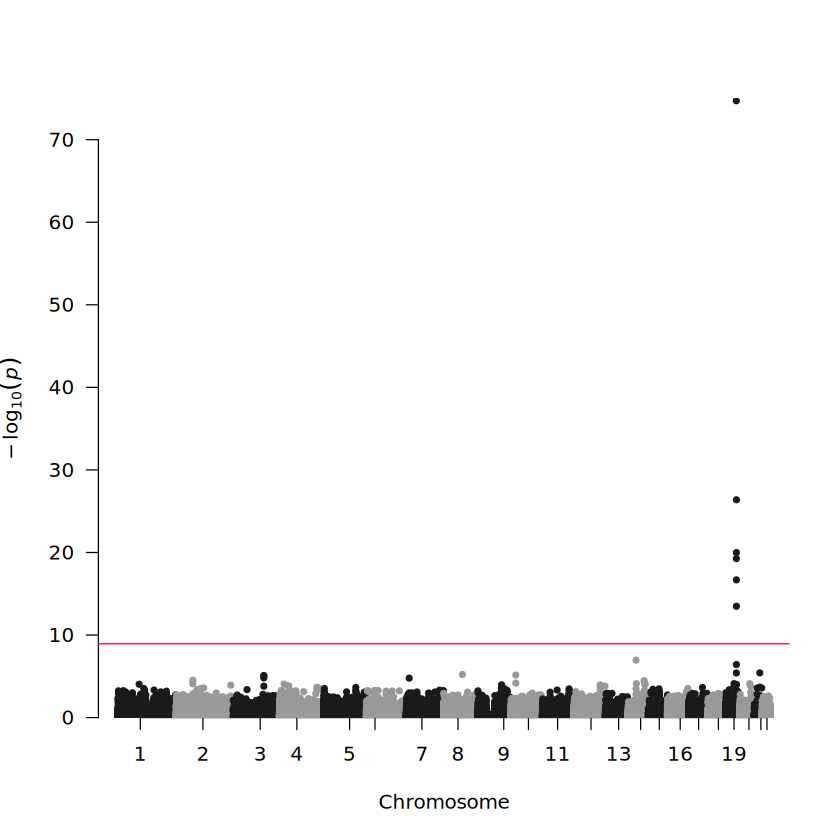

In [74]:
## manhattan plot
thres = 0.05 / (nrow(delir) * 445)

apoe1 = 45309039
apoe2 = 45512650 
apoechr = 19

delir2 = 
delir %>%
    mutate(apoe = ifelse( chr == apoechr & pos > apoe1 & pos < apoe2 , 1, 0))

apoe_cpgs = delir2 %>% filter(apoe == 1) %>% pull(cpg)
  
manhattan(
    delir,
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    annotateTop = TRUE
)

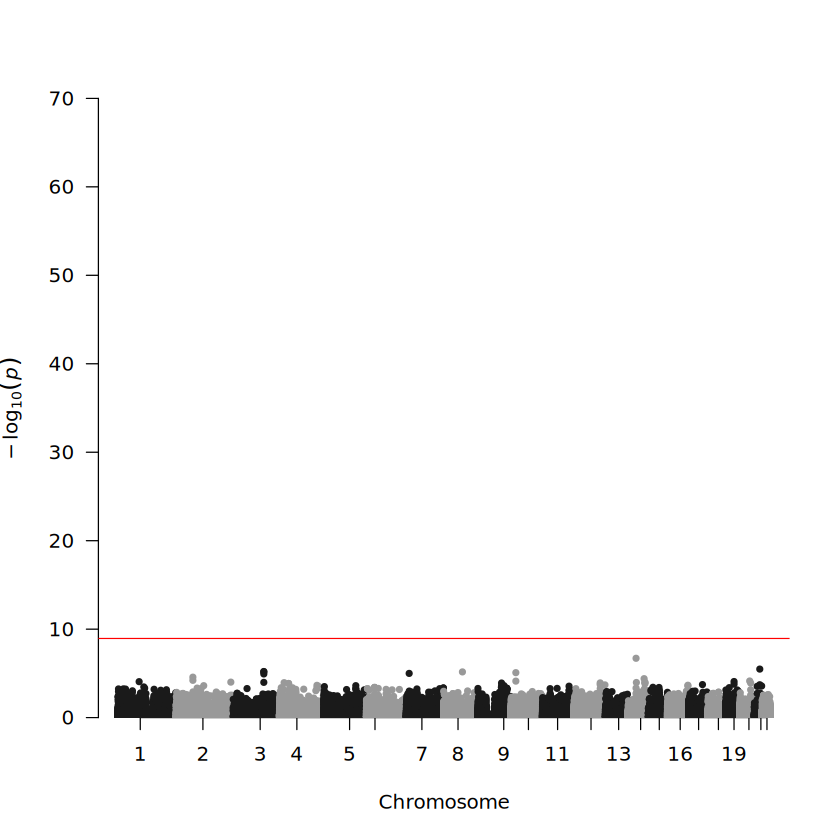

In [22]:
manhattan(
    delir_e4adj, 
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    ylim = c(0,70)
)

In [27]:
delir_signif = delir %>% filter(pvalue < thres) %>% select(1,2,4,5,6,7)
delir_signif
delir_e4adj %>% filter(cpg %in% delir_signif$cpg) %>% select(1,2,4,5,6,7)

cpg,beta,lci,uci,zscore,pvalue
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cg25727206,-0.004072438,-0.004506621,-0.003638255,-18.383615,1.906883e-75
cg20051876,0.002068501,0.001634184,0.002502817,9.334661,1.017982e-20
cg14123992,0.001681426,0.001247093,0.002115758,7.587607,3.265522e-14
cg04406254,0.002028522,0.001594204,0.002462841,9.154210,5.499889e-20
cg17928676,0.001881354,0.001447029,0.002315679,8.489956,2.073939e-17
cg24640084,0.002389557,0.001955256,0.002823858,10.783898,4.136023e-27


cpg,beta,lci,uci,zscore,pvalue
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
cg25727206,-3.673221e-04,-0.0008010393,6.639514e-05,-1.65992991,0.09692932
cg20051876,-1.820720e-04,-0.0006157903,2.516464e-04,-0.82278179,0.41063257
cg14123992,-3.689863e-04,-0.0008027035,6.473087e-05,-1.66745071,0.09542558
cg04406254,-2.255731e-04,-0.0006592912,2.081451e-04,-1.01936344,0.30803106
cg17928676,9.502146e-05,-0.0003386971,5.287400e-04,0.42940103,0.66763163
cg24640084,1.374304e-05,-0.0004199756,4.474617e-04,0.06210464,0.95047953


### dementia 

In [ ]:
## load unadjusted
dem = fread('/mnt/project/vasilis/data/ebb/results_clean/NS_328.1_mwas_assoc.csv')
# load adjusted
system('dx download -f --no-progress vasilis/data/ebb/results_clean/NS_328.1_e4adj_mwas_assoc.csv')
dem_e4adj = fread('NS_328.1_e4adj_mwas_assoc.csv')


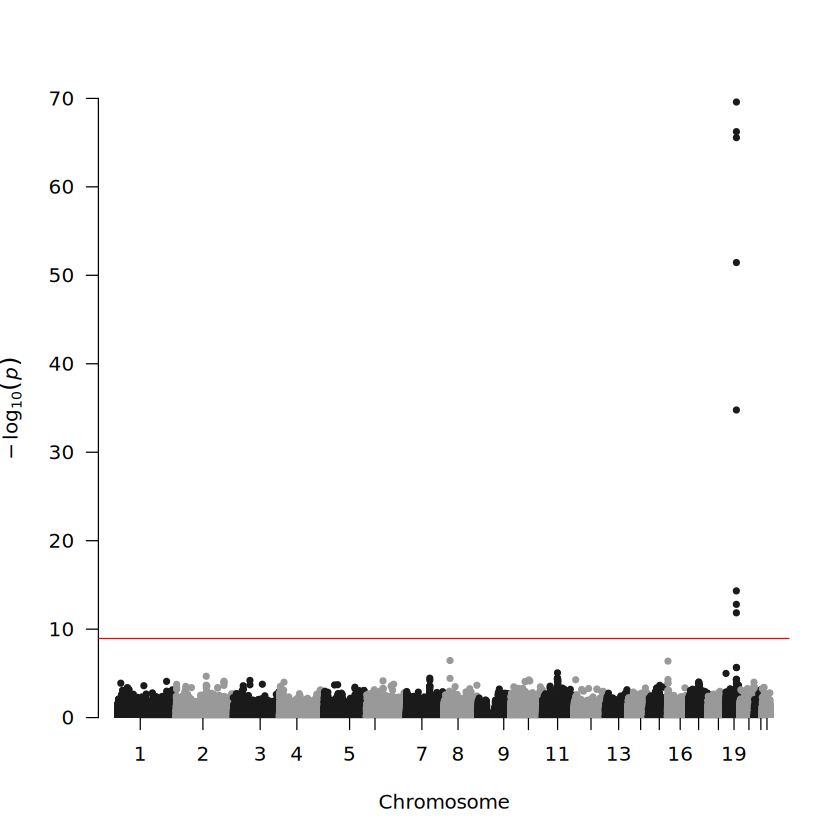

In [33]:
manhattan(
    dem, 
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    ylim = c(0,70)
)

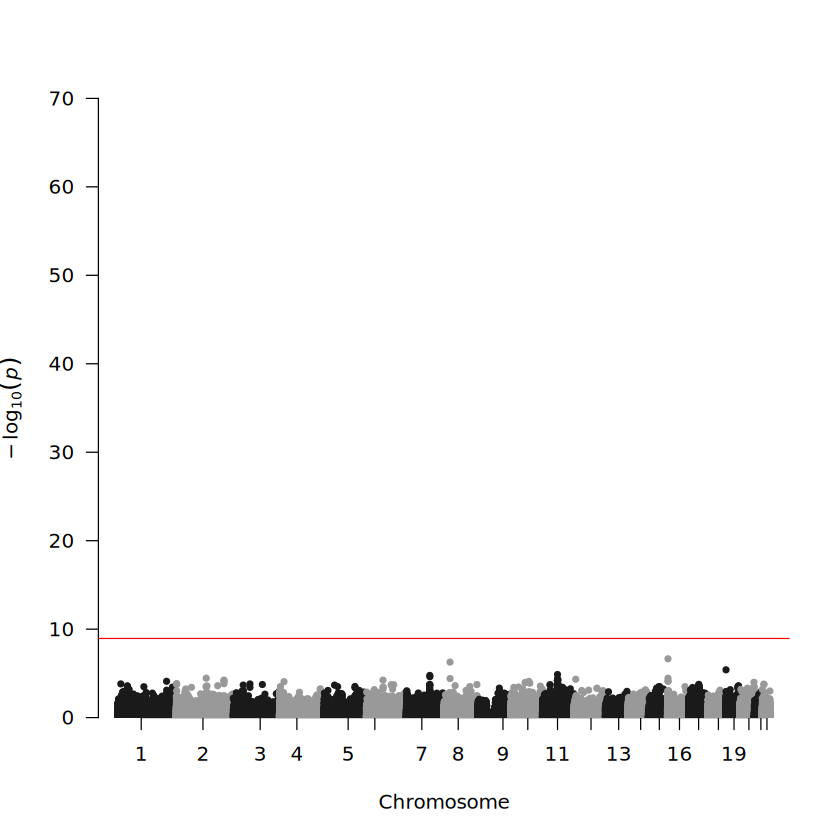

In [34]:
manhattan(
    dem_e4adj, 
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    ylim = c(0,70)
)

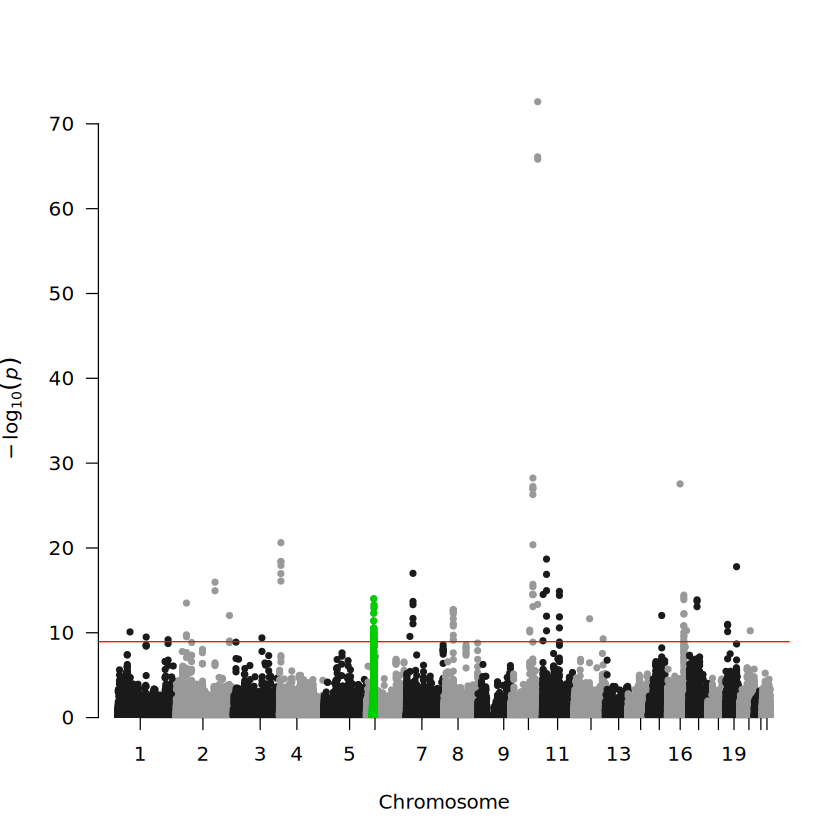

In [75]:
test = fread('/mnt/project/vasilis/data/ebb/results_clean/EM_200.1_mwas_assoc.csv') # Hypothyroidism
test = fread('/mnt/project/vasilis/data/ebb/results_clean/EM_202.2_mwas_assoc.csv') #t2d
#test = fread('/mnt/project/vasilis/data/ebb/results_clean/EM_202.1_mwas_assoc.csv') #t1d


hla1 = 25000000
hla2 = 34000000
hlachr = 6

test = 
test %>% 
    mutate(pvalue = pvalue + 1e-100) %>% 
    mutate(hla = ifelse( chr == hlachr & pos > hla1 & pos < hla2 , 1, 0))

hla_cpgs = test %>% filter(hla == 1) %>% pull(cpg)
    

manhattan(
    test, 
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    highlight = hla_cpgs
)

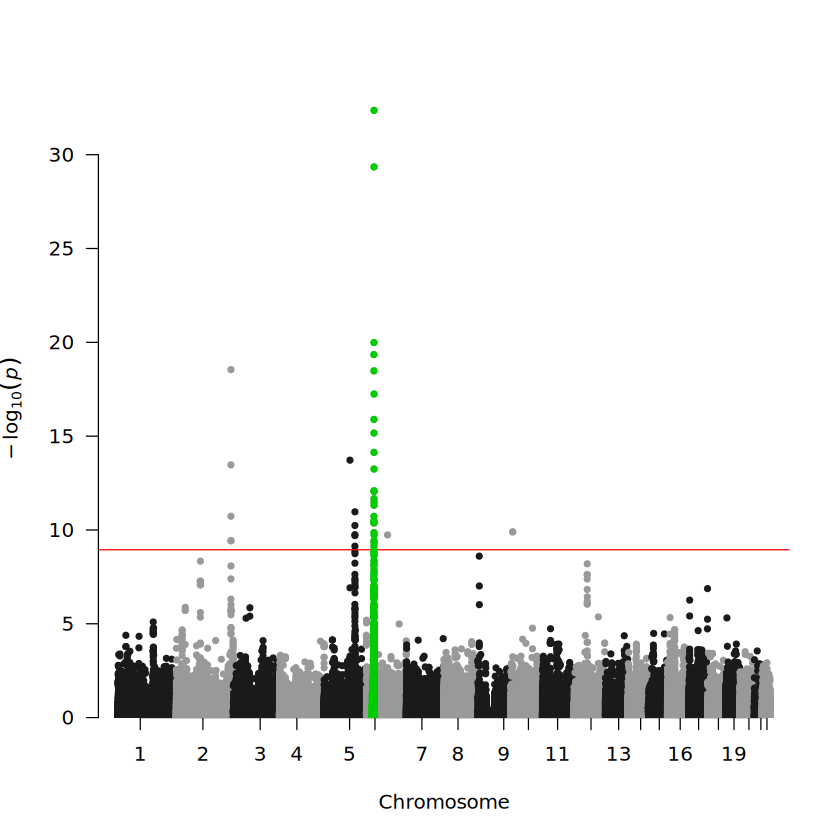

In [60]:
test = fread('/mnt/project/vasilis/data/ebb/results_clean/CA_135.5_mwas_assoc.csv') #t1d


hla1 = 25000000
hla2 = 34000000
hlachr = 6

test = 
test %>% 
    mutate(pvalue = pvalue + 1e-100) %>% 
    mutate(hla = ifelse( chr == hlachr & pos > hla1 & pos < hla2 , 1, 0))

hla_cpgs = test %>% filter(hla == 1) %>% pull(cpg)
    

manhattan(
    test, 
    snp = 'cpg', chr = 'chr', p = 'pvalue', bp = 'pos', 
    genomewideline = -1*log10(thres),
    suggestiveline = FALSE,
    highlight = hla_cpgs
)